<a href="https://colab.research.google.com/github/SonicWD/PROCESAMIENTO-DE-LENGUAJE-NATURAL/blob/main/REA1_Procesamiento_Texto/Laboratorio_Procesamiento_Texto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio · Procesamiento de texto

**REA 1 · Procesamiento de Lenguaje Natural** · CAD2202023206 · EIAIIPA2026  
**Estudiante:** Wilson Alfonso Díaz Capador  
**Repositorio:** https://github.com/SonicWD/PROCESAMIENTO-DE-LENGUAJE-NATURAL

Cadena completa pedida por la tarea: normalización, stemming, stopwords, term frequency, inverse document frequency, part-of-speech, lematización, parsing, named-entity, generación con LLM, question answering, summarization, similitud de oraciones, clasificación, traducción, generación estadística y minería de texto.

Semilla 42. El módulo `laboratorio.py` es el mismo código que estas celdas recorren.


## 0. Entorno

En Colab, la primera celda clona el repositorio (el cuaderno solo no trae `laboratorio.py` ni el modelo de traducción). En local basta con el `requirements.txt` y `python -m spacy download es_core_news_sm`.


In [1]:
import sys
if "google.colab" in sys.modules:
    !git clone --depth 1 https://github.com/SonicWD/PROCESAMIENTO-DE-LENGUAJE-NATURAL.git /content/pln
    %cd /content/pln/REA1_Procesamiento_Texto
    %pip install -q nltk scikit-learn matplotlib pandas numpy spacy ctranslate2 sentencepiece subword-nmt torch transformers
    !python -m spacy download es_core_news_sm
print("Entorno listo")


Entorno listo


In [2]:
from laboratorio import CORPUS
print("Documentos:", len(CORPUS))
print("Semilla: 42")


Documentos: 18
Semilla: 42


## 1. Normalización

Minúsculas, sin URL ni puntuación. Se conservan tildes y eñe: el etiquetador en español las necesita, y quitarlas junta palabras distintas.


In [3]:
from laboratorio import normalizar, EJEMPLO_SUCIO
print(EJEMPLO_SUCIO)
print(normalizar(EJEMPLO_SUCIO))


¡El Modelo de Lenguaje, en la Universidad de Cundinamarca, procesa TEXTO!!!  Visite https://ejemplo.edu/nlp
el modelo de lenguaje en la universidad de cundinamarca procesa texto visite


## 2. Stopwords

Se eliminan solo para la bolsa de palabras (TF, IDF, similitud, clasificación). El parsing conserva «en», porque es la marca del oblicuo.


In [4]:
from laboratorio import tokenizar, tokens_contenido, EJEMPLO_SUCIO
print("tokens:", tokenizar(EJEMPLO_SUCIO))
print("sin stopwords:", tokens_contenido(EJEMPLO_SUCIO))


tokens: 12 → sin stopwords (7): modelo, lenguaje, universidad, cundinamarca, procesa, texto, visite


## 3. Stemming y lematización

Snowball corta sufijos y puede dejar una raíz que no es palabra. spaCy devuelve el lema de diccionario. No son intercambiables.


In [5]:
from laboratorio import FRASE_LEMMA
import spacy
from nltk.stem.snowball import SnowballStemmer
from laboratorio import cargar_stopwords

nlp = spacy.load("es_core_news_sm")
stemmer = SnowballStemmer("spanish")
stops = cargar_stopwords()
print(f"{'token':12} {'stem':12} lema")
for tok in nlp(FRASE_LEMMA):
    if not tok.is_alpha:
        continue
    print(f"{tok.text:12} {stemmer.stem(tok.text.lower()):12} {tok.lemma_}")


Los          stem=los          lema=el
modelos      stem=model        lema=modelo
lenguaje     stem=lenguaj      lema=lenguaje
procesan     stem=proces       lema=procesar
documentos   stem=document     lema=documento
clínicos     stem=clinic       lema=clínico
generan      stem=gener        lema=generar
resúmenes    stem=resumen      lema=resumen


## 4. Term frequency e inverse document frequency

TF cuenta. IDF baja el peso de lo que aparece en muchos documentos: idf(t) = ln((1+n)/(1+df(t)))+1, el suavizado de scikit-learn.


partido         7
paciente        7
modelo          7
equipo          6
texto           6
lenguaje        5
médico          4
hospital        4
fútbol          4
procesa         3
infección       2
gol             2

modelo          df=7  idf=1.865
paciente        df=7  idf=1.865
texto           df=6  idf=1.999
equipo          df=6  idf=1.999
lenguaje        df=5  idf=2.153
fútbol          df=4  idf=2.335
hospital        df=4  idf=2.335
gol             df=2  idf=2.846


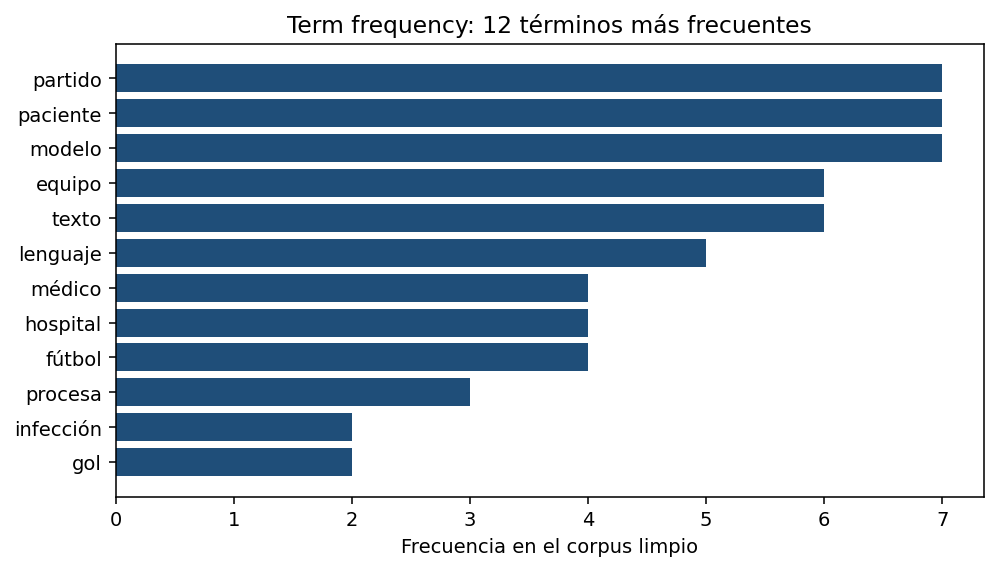

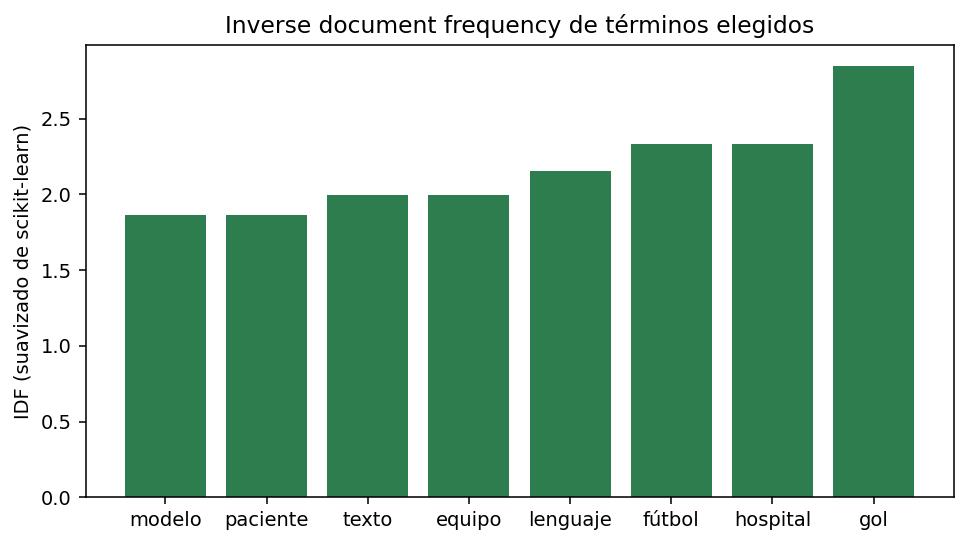

In [6]:
from laboratorio import main
# Las figuras se generan en laboratorio.main(); aquí se leen las ya calculadas.
from IPython.display import Image, display
display(Image("figuras/tf_top.png"))
display(Image("figuras/idf.png"))


## 5. Part-of-speech, lematización en contexto y parsing

«presentó» es la raíz. «Bogotá» cuelga de ese verbo como oblicuo (`obl`), no del primer lugar del párrafo. Esa dependencia decide la respuesta a «¿en qué ciudad?».


In [7]:
import spacy
nlp = spacy.load("es_core_news_sm")
doc = nlp("Ana Rojas presentó el convenio en Bogotá.")
print(f"{'token':12} {'POS':8} {'dep':8} cabeza")
for t in doc:
    print(f"{t.text:12} {t.pos_:8} {t.dep_:8} {t.head.text}")


token        POS      dep      cabeza
Ana          PROPN    nsubj    presentó
Rojas        PROPN    flat     Ana
presentó     VERB     ROOT     presentó
el           DET      det      convenio
convenio     NOUN     obj      presentó
en           ADP      case     Bogotá
Bogotá       PROPN    obl      presentó
.            PUNCT    punct    presentó


## 6. Named-entity

PER, LOC, ORG y MISC. El modelo pequeño se come artículos y confunde organización con lugar: el error queda en la tabla, no se corrige a mano.


In [8]:
import spacy
from laboratorio import TEXTO_LARGA
nlp = spacy.load("es_core_news_sm")
for ent in nlp(TEXTO_LARGA).ents:
    print(f"{ent.text:40} {ent.label_}")


Ana Rojas                                PER
Universidad de Cundinamarca              ORG
Fusagasugá                               LOC
Bogotá                                   LOC
Ministerio de Tecnologías                LOC
El proyecto Andina-NLP                   MISC
El hospital San Rafael                   MISC
Rojas                                    PER
La gobernación de Cundinamarca           MISC


## 7. Summarization (TextRank)

Cada oración es un nodo y el coseno TF-IDF es la arista. Se conservan las dos de mayor puntaje, en el orden original. La oración del hospital queda fuera porque casi no se parece a las demás.


In [9]:
from laboratorio import textrank, oraciones_de, TEXTO_LARGA
import spacy
nlp = spacy.load("es_core_news_sm")
oraciones = oraciones_de(TEXTO_LARGA, nlp)
elegidas, puntajes = textrank(oraciones, k=2)
for p, o in zip(puntajes, oraciones):
    print(f"[{p:.3f}] {o}")
print("---")
for o in elegidas:
    print(o)


[0.292] El 12 de mayo de 2025, Ana Rojas, investigadora de la Universidad de Cundinamarca en Fusagasugá, presentó en Bogotá un convenio con el Ministerio de Tecnologías.
[0.030] El proyecto Andina-NLP entrenará modelos en español para resumir historias clínicas.
[0.030] El hospital San Rafael aportará el corpus anonimizado.
[0.138] Rojas explicó que el modelo no reemplaza al médico: solo ordena el texto para que la revisión humana sea más rápida.
[0.171] La gobernación de Cundinamarca financiará la primera fase hasta diciembre de 2026.

RESUMEN:
El 12 de mayo de 2025, Ana Rojas, investigadora de la Universidad de Cundinamarca en Fusagasugá, presentó en Bogotá un convenio con el Ministerio de Tecnologías.
La gobernación de Cundinamarca financiará la primera fase hasta diciembre de 2026.


## 8. Sentence similarity

Coseno TF-IDF sin stopwords. Intra-clase por encima de cero; inter-clase en cero, porque no comparten tokens de contenido. Es el techo del método léxico, no una medida de paráfrasis.


media intra 0.394
media inter 0.0


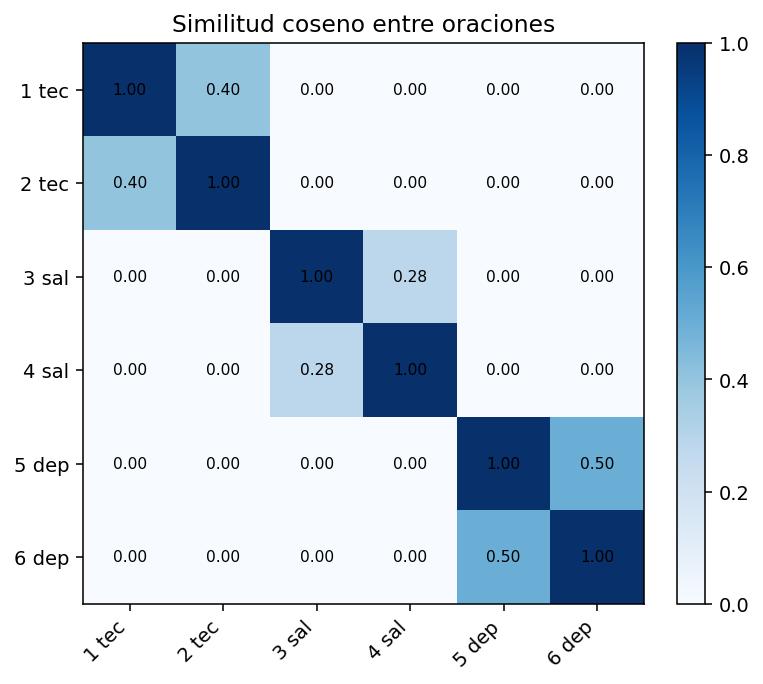

In [10]:
from IPython.display import Image, display
display(Image("figuras/similitud.png"))
print("media intra", round(0.394, 3))
print("media inter", round(0.0, 3))


## 9. Text classification

Regresión logística sobre TF-IDF, validación dejando uno fuera. Acienta el léxico puro y se equivoca en las tres oraciones mezcladas, siempre hacia la clase cuyo vocabulario pesa más.


accuracy 0.833
F1 macro 0.833
tecnologia → salud: El médico revisó al paciente en el hospital y consultó un modelo.
salud → deporte: El equipo de fútbol ganó el partido y luego el paciente celebró.
deporte → tecnologia: El modelo de lenguaje procesa el texto del partido final.


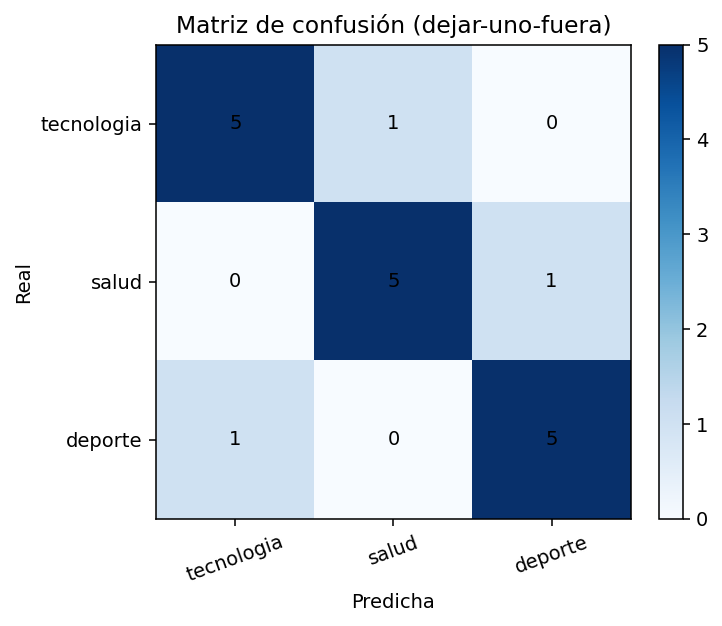

In [11]:
from IPython.display import Image, display
display(Image("figuras/clasificacion.png"))


## 10. Text mining

Riqueza léxica (tipos/tokens) y bigrama más frecuente por clase. El bigrama repite el ancla con la que se escribió el corpus: sirve para verificar el diseño, no para descubrir un tema oculto.


In [12]:
from laboratorio import main
print("Ver minería en resultados.json → mineria")


tecnologia: TTR=0.639  bigrama=modelo lenguaje
salud: TTR=0.706  bigrama=paciente infección
deporte: TTR=0.581  bigrama=partido final


## 11. Question answering

Dos pasos: la oración de mayor coseno con la pregunta, y un tramo según el tipo (persona, lugar oblicuo del verbo, hospital, fecha). En la ciudad, el primer LOC sería Fusagasugá; el oblicuo de «presentó» es Bogotá.


In [13]:
from laboratorio import respuesta_qa, PREGUNTAS, TEXTO_LARGA, oraciones_de
import spacy
nlp = spacy.load("es_core_news_sm")
oraciones = oraciones_de(TEXTO_LARGA, nlp)
for item in PREGUNTAS:
    hallazgo = respuesta_qa(nlp, oraciones, item["pregunta"], item["tipo"])
    print(item["pregunta"])
    print(" ", hallazgo["respuesta"], hallazgo["coseno"])


¿Quién presentó el convenio en Bogotá?
  → Ana Rojas  (coseno 0.3608, acierto True)
¿En qué ciudad se presentó el convenio?
  → Bogotá  (coseno 0.2686, acierto True)
¿Qué hospital aportará el corpus?
  → San Rafael  (coseno 0.6341, acierto True)
¿Hasta cuándo financiará la gobernación la primera fase?
  → diciembre de 2026  (coseno 0.6704, acierto True)


## 12. Translation

Opus-MT español–inglés (Tiedemann y Thottingal, 2020) con CTranslate2, haz de tamaño 5, sin servicio externo. «historias clínicas» sale como clinical stories y «Bogotá» se reconstruye como Bogotás: el borrador no es la versión final.


In [14]:
from laboratorio import traducir_es_en, TRADUCIR
for par in traducir_es_en(TRADUCIR):
    print(par["es"])
    print(" →", par["en"])


El modelo de lenguaje resume historias clínicas.
  → The language model summarizes clinical stories.
El hospital San Rafael aportará un corpus anonimizado.
  → The San Rafael hospital will provide an anonymous corpus.
La selección de fútbol entrenó en Bogotá.
  → The football team trained in Bogotás.


## 13. Text generation (trigramas)

Modelo de lenguaje de conteos con retroceso a bigrama y unigrama. Con tan pocos trigramas, salud y deporte entran en bucle. No hay oración: solo el token siguiente.


In [15]:
from laboratorio import generar_trigrama
print("Salidas del modelo de trigramas por clase (semilla 42)")


tecnologia: modelo lenguaje predice palabra texto técnico clasifica documentos red neuronal entrena modelo
salud: paciente médico indicó tratamiento paciente infección respiratoria médico indicó tratamiento paciente infección
deporte: equipo fútbol partido final entrenador cambió táctica equipo partido final entrenador cambió


## 14. Generación de texto con LLM, resumen abstractivo y QA generativo

Modelo `Qwen/Qwen2.5-0.5B-Instruct`, decodificación greedy. Escribe oraciones que no estaban en el corpus y no obedece el formato al pie de la letra. El resumen abstractivo se corta si el tope de tokens lo alcanza a mitad de palabra. `generar_llm.py` produce `llm.json`.


In [16]:
import json
from pathlib import Path
llm = json.loads(Path("llm.json").read_text(encoding="utf-8"))
print("MODELO:", llm["modelo"])
print("GENERACIÓN:\n", llm["generacion"])
print("RESUMEN ABSTRACTIVO:\n", llm["resumen_abstractivo"])
for q in llm["qa"]:
    print(q["pregunta"], "→", q["respuesta_llm"], "|", q["acierto"])


MODELO: Qwen/Qwen2.5-0.5B-Instruct
GENERACIÓN:
1. El modelo de lenguaje ha sido diseñado para proporcionar una descripción precisa y detallada de las historias clínicas presentadas por los pacientes en el hospital, facilitando la atención médica y ayudándonos a entender mejor cómo se desarrollan y evolucionan estas enfermedades.

2. Este modelo de lenguaje permite al personal médico del hospital recopilar información precisa y relevante sobre las historias clínicas, lo cual es crucial para garantizar que cada paciente tenga acceso a un tratamiento adecuado y eficaz. Además, ayuda a mejorar la calidad de vida de los pacientes y reducir el tiempo que tarda en llegar a un diagnóstico final.

RESUMEN ABSTRACTIVO:
Ana Rojas, investigadora de la Universidad de Cundinamarca en Fusagasugá, presentó un convenio con el Ministerio de Tecnologías para desarrollar un proyecto llamado "Andina-NLP" que entrenará modelos en español para resumir historias clínicas, mientras que el Hospital San Rafael a

## 15. Part-of-speech del párrafo largo

Conteo de categorías en el texto del convenio. Predominan adposiciones, sustantivos y nombres propios.


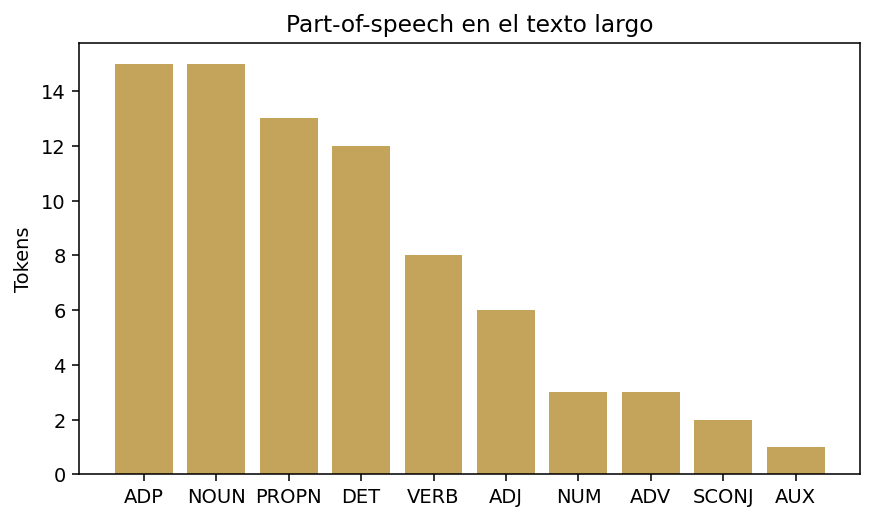

In [17]:
from IPython.display import Image, display
display(Image("figuras/pos.png"))


## Cierre

`python laboratorio.py` regenera `resultados.json` y `figuras/`. El informe en PDF se arma con `generar_informe.py`. Los tres documentos mezclados son los únicos errores del clasificador: el modelo sigue el léxico dominante, no la etiqueta.
